# 📘 End-to-End Guide to Machine Learning Regression (with Logarithmic Models)


## 1. Introduction to Machine Learning

**What is Machine Learning?**  
Machine learning (ML) is the study of algorithms that improve automatically through experience.

**Types of ML:**
- Supervised Learning (e.g., Regression, Classification)
- Unsupervised Learning (e.g., Clustering, Dimensionality Reduction)
- Reinforcement Learning

**Real-world Examples:**
- House Price Prediction
- Sales Forecasting
- Customer Lifetime Value estimation



## 2. Supervised Learning: Focus on Regression

**What is Regression?**  
Regression is a type of supervised learning used to predict continuous outcomes.

**Types of Regression:**
- Linear Regression
- Polynomial Regression
- Ridge, Lasso
- Logarithmic Regression (Focus of this notebook)


## 3. Dataset Setup

In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load California housing dataset
data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 4. Exploratory Data Analysis (EDA)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


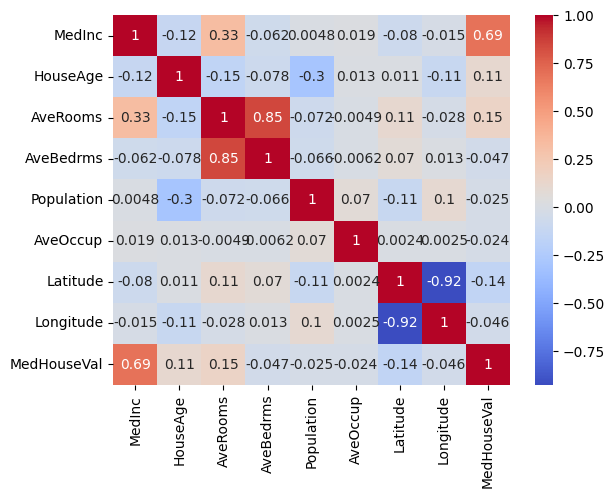

number of nulls 
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
na valus 
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

MedInc: 681 outliers
HouseAge: 0 outliers
AveRooms: 511 outliers
AveBedrms: 1424 outliers
Population: 1196 outliers
AveOccup: 711 outliers
Latitude: 0 outliers
Longitude: 0 outliers
MedHouseVal: 1071 outliers

 MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


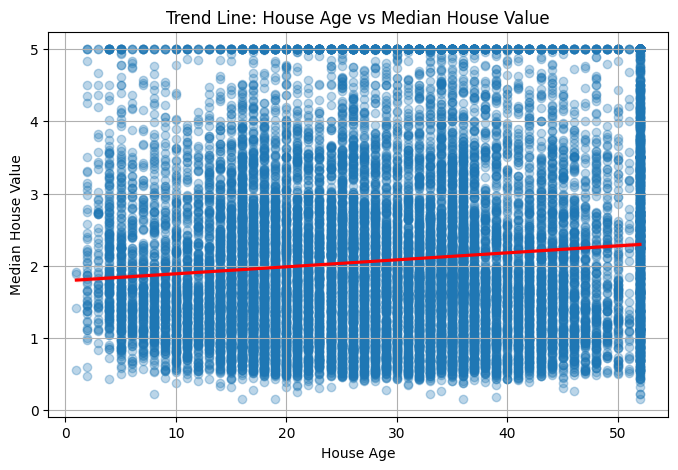

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

# Basic statistics and correlation
display(df.describe())
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()


## Find out if there are any null values in any of the columns 

print("number of nulls \n",df.isnull().sum())
print("na valus \n",df.isna().sum())



# Find out if there are outliers
print()
for col in df.select_dtypes(include='number').columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f'{col}: {len(outliers)} outliers')


# Find out which are categorical & numerical Variables
print("\n",df.dtypes)




# Plot a trend line graph for housing prices
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='HouseAge', y='MedHouseVal', scatter_kws={'alpha':0.3}, line_kws={"color":"red"})
plt.title("Trend Line: House Age vs Median House Value")
plt.xlabel("House Age")
plt.ylabel("Median House Value")
plt.grid(True)
plt.show()



#trend lins


## 5. Data Preprocessing

In [8]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled)
X_test_scaled


[[-0.326196    0.34849025 -0.17491646 ...  0.05137609 -1.3728112
   1.27258656]
 [-0.03584338  1.61811813 -0.40283542 ... -0.11736222 -0.87669601
   0.70916212]
 [ 0.14470145 -1.95271028  0.08821601 ... -0.03227969 -0.46014647
  -0.44760309]
 ...
 [-0.49697313  0.58654547 -0.60675918 ...  0.02030568 -0.75500738
   0.59946887]
 [ 0.96545045 -1.07984112  0.40217517 ...  0.00707608  0.90651045
  -1.18553953]
 [-0.68544764  1.85617335 -0.85144571 ... -0.08535429  0.99543676
  -1.41489815]]


array([[-1.15508475, -0.28632369, -0.52068576, ...,  0.06740798,
         0.1951    ,  0.28534728],
       [-0.70865905,  0.11043502, -0.16581537, ..., -0.03602975,
        -0.23549054,  0.06097472],
       [-0.21040155,  1.85617335, -0.61076476, ..., -0.14998876,
         1.00947776, -1.42487026],
       ...,
       [ 2.80902421, -0.28632369,  0.75501156, ..., -0.02646898,
         0.78014149, -1.23041404],
       [-0.57542978,  0.58654547, -0.06124296, ..., -0.04390537,
         0.52740357, -0.08860699],
       [-0.17259111, -0.92113763, -0.6058703 , ...,  0.05466644,
        -0.66608108,  0.60445493]], shape=(4128, 8))

## 6. Linear Regression

In [6]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))


R² Score: 0.5757877060324508
RMSE: 0.7455813830127764


C:\Users\S Vishnu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(



## 7. Logarithmic Regression

Logarithmic models are useful when the data exhibits exponential growth/decay. We can apply log transformations to the target, features, or both.


In [6]:

import numpy as np

# Log transform target
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

lr_log = LinearRegression()
lr_log.fit(X_train_scaled, y_train_log)
y_pred_log = lr_log.predict(X_test_scaled)

# Inverse transform
y_pred_actual = np.expm1(y_pred_log)

print("R² Score (Log Target):", r2_score(y_test, y_pred_actual))
print("RMSE (Log Target):", mean_squared_error(y_test, y_pred_actual, squared=False))


R² Score (Log Target): 0.26573833752374054
RMSE (Log Target): 0.9809093102254558


C:\Users\S Vishnu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## 8. Compare Models

In [7]:

results = pd.DataFrame({
    'Model': ['Linear', 'Log Target'],
    'R2 Score': [r2_score(y_test, y_pred), r2_score(y_test, y_pred_actual)],
    'RMSE': [mean_squared_error(y_test, y_pred, squared=False),
             mean_squared_error(y_test, y_pred_actual, squared=False)]
})
results


C:\Users\S Vishnu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\S Vishnu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,Model,R2 Score,RMSE
0,Linear,0.575788,0.745581
1,Log Target,0.265738,0.980909



## 9. Key Takeaways

- Regression helps predict continuous values.
- Logarithmic transformation can improve model performance when exponential patterns exist.
- Always evaluate models using metrics and residual patterns.
